##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
!pip install -q transformers torchvision scikit-learn pillow requests

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel, AutoModelForImageClassification
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.stats import mode
import requests
from io import BytesIO

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [9]:
dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True
)

cat_breeds = [
    "Abyssinian", "Bengal", "Birman", "Bombay", "British_Shorthair",
    "Egyptian_Mau", "Maine_Coon", "Persian", "Ragdoll",
    "Russian_Blue", "Siamese", "Sphynx"
]

cat_indices = []
dog_indices = []

for i in range(len(dataset)):
    img, label = dataset[i]
    breed_name = dataset.classes[label]

    if breed_name in cat_breeds and len(cat_indices) < 10:
        cat_indices.append(i)
    elif breed_name not in cat_breeds and len(dog_indices) < 10:
        dog_indices.append(i)

selected_indices = cat_indices + dog_indices

images = []
true_labels = []

for idx in selected_indices:
    img, label = dataset[idx]
    breed_name = dataset.classes[label]

    images.append(img.convert("RGB"))

    if breed_name in cat_breeds:
        true_labels.append(0)   # Cat
    else:
        true_labels.append(1)   # Dog

true_labels = np.array(true_labels)

print("Total:", len(images))
print("Cats:", np.sum(true_labels == 0))
print("Dogs:", np.sum(true_labels == 1))

Total: 20
Cats: 10
Dogs: 10


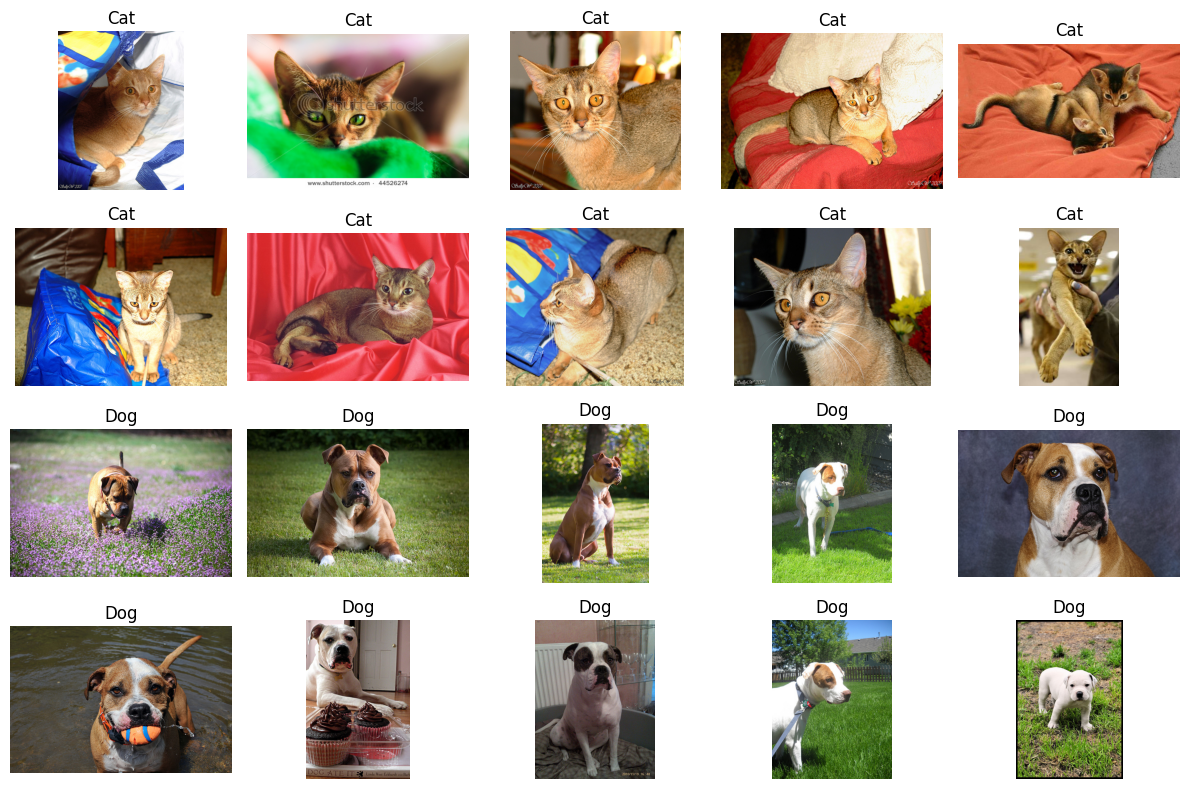

In [10]:
fig, axes = plt.subplots(4, 5, figsize=(12, 8))

for ax, img, label in zip(axes.flatten(), images, true_labels):
    ax.imshow(img)
    ax.set_title("Cat" if label == 0 else "Dog")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
model = AutoModel.from_pretrained("facebook/dinov2-small").to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((384,), eps=1e-06,

In [12]:
cls_tokens = []

with torch.no_grad():
    for img in images:
        inputs = processor(images=img, return_tensors="pt").to(device)
        outputs = model(**inputs)

        cls_token = outputs.last_hidden_state[:, 0, :]
        cls_token = cls_token.cpu().numpy().flatten()

        cls_tokens.append(cls_token)

cls_tokens = np.array(cls_tokens)

print("CLS token shape:", cls_tokens.shape)

CLS token shape: (20, 384)


In [13]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cls_tokens)

print("Predicted clusters:", clusters)
print("Ground truth labels:", true_labels)

Predicted clusters: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Ground truth labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [14]:
aligned_clusters = np.zeros_like(clusters)

for cluster_id in np.unique(clusters):
    mask = clusters == cluster_id
    majority_label = mode(true_labels[mask], keepdims=True).mode[0]
    aligned_clusters[mask] = majority_label

accuracy = accuracy_score(true_labels, aligned_clusters)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(true_labels, aligned_clusters, target_names=["Cat", "Dog"]))

print("Confusion Matrix:")
print(confusion_matrix(true_labels, aligned_clusters))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00        10
         Dog       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Confusion Matrix:
[[10  0]
 [ 0 10]]


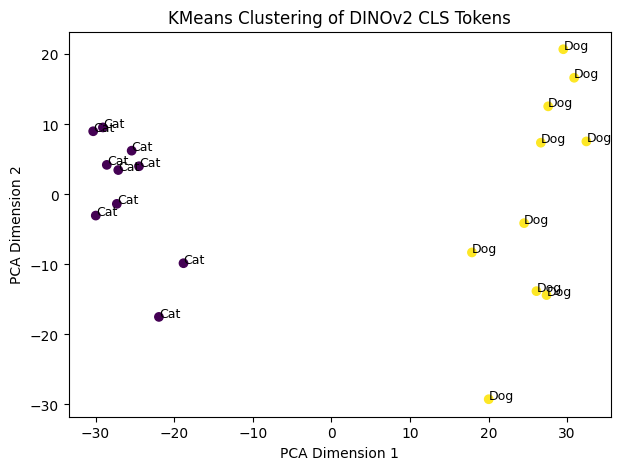

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
cls_2d = pca.fit_transform(cls_tokens)

plt.figure(figsize=(7, 5))
plt.scatter(cls_2d[:, 0], cls_2d[:, 1], c=clusters)

for i, label in enumerate(true_labels):
    text = "Cat" if label == 0 else "Dog"
    plt.text(cls_2d[i, 0], cls_2d[i, 1], text, fontsize=9)

plt.title("KMeans Clustering of DINOv2 CLS Tokens")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [16]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import torch

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)
classifier = AutoModelForImageClassification.from_pretrained(model_id).to(device)
classifier.eval()

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Dinov2ForImageClassification(
  (dinov2): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2Laye

In [27]:
!find /content -iname "*Golden*"

/content/Golden_Retriever_Dukedestiny01_drvd.jpg


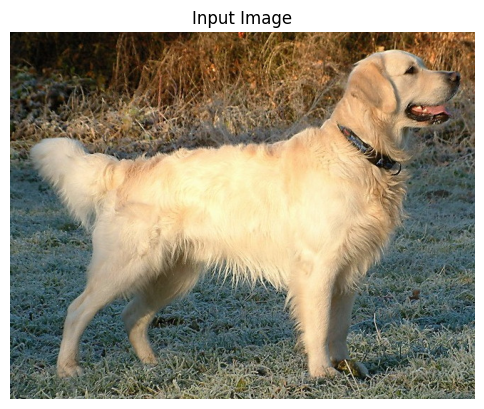

In [28]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "/content/Golden_Retriever_Dukedestiny01_drvd.jpg"

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [29]:
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = classifier(**inputs)
    predicted_class_id = outputs.logits.argmax(-1).item()

predicted_label = classifier.config.id2label[predicted_class_id]

print("Predicted Class ID:", predicted_class_id)
print("Predicted Label:", predicted_label)

Predicted Class ID: 207
Predicted Label: golden retriever
